## Exploratory Data Analysis

#### PHASE 1 — DATA INSPECTION & INTEGRITY

In [6]:
# shape and size
print("DATASET SHAPE")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Total cells: {df.size:,}")

DATASET SHAPE
Rows: 41,188
Columns: 21
Total cells: 864,948


In [7]:
# Concise summary (non-null counts + dtypes + memory usage)
print("DATAFRAME INFO")
df.info()

DATAFRAME INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   

In [8]:
# Check for duplicate rows
print("DUPLICATE ROWS CHECK")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage of duplicates: {duplicates/len(df)*100:.2f}%")

DUPLICATE ROWS CHECK
Number of duplicate rows: 12
Percentage of duplicates: 0.03%


In [9]:
# Check for traditional null values (should be zero — unknowns are the real issue)
print("NULL VALUE CHECK")
print(df.isnull().sum())

NULL VALUE CHECK
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [11]:
# Count 'unknown' values per column
print("'UNKNOWN' VALUES PER COLUMN")

unknown_summary = {}
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        unknown_pct = unknown_count / len(df) * 100
        unknown_summary[col] = {
            'count': unknown_count,
            'percentage': round(unknown_pct, 2)
        }

unknown_df = pd.DataFrame(unknown_summary).T.sort_values('count', ascending=False)
print(unknown_df)


# Does having "unknown" in a column correlate with conversion?
print("\n" + "-"*40)
print("CONVERSION RATE: KNOWN vs UNKNOWN VALUES")

for col in unknown_df.index:
    known_rate = (df[df[col] != 'unknown']['y'] == 'yes').mean() * 100
    unknown_rate = (df[df[col] == 'unknown']['y'] == 'yes').mean() * 100
    print(f"\n{col}:")
    print(f"  Known values   → {known_rate:.2f}% conversion")
    print(f"  Unknown values → {unknown_rate:.2f}% conversion")
    print(f"  Difference     → {unknown_rate - known_rate:+.2f} pp")

# Check if rows have multiple unknowns (data quality red flag)
print("\n" + "-"*40)
print("ROWS WITH MULTIPLE UNKNOWN VALUES")

unknown_cols = list(unknown_df.index)
df['unknown_count'] = (df[unknown_cols] == 'unknown').sum(axis=1)

print(df['unknown_count'].value_counts().sort_index())
print(f"\nRows with 0 unknowns: {(df['unknown_count'] == 0).sum():,} ({(df['unknown_count'] == 0).mean()*100:.1f}%)")
print(f"Rows with 1+ unknowns: {(df['unknown_count'] >= 1).sum():,} ({(df['unknown_count'] >= 1).mean()*100:.1f}%)")
print(f"Rows with 2+ unknowns: {(df['unknown_count'] >= 2).sum():,} ({(df['unknown_count'] >= 2).mean()*100:.1f}%)")
print("\n" + "-"*40)

'UNKNOWN' VALUES PER COLUMN
            count  percentage
default    8597.0       20.87
education  1731.0        4.20
housing     990.0        2.40
loan        990.0        2.40
job         330.0        0.80
marital      80.0        0.19

----------------------------------------
CONVERSION RATE: KNOWN vs UNKNOWN VALUES

default:
  Known values   → 12.88% conversion
  Unknown values → 5.15% conversion
  Difference     → -7.72 pp

education:
  Known values   → 11.12% conversion
  Unknown values → 14.50% conversion
  Difference     → +3.38 pp

housing:
  Known values   → 11.28% conversion
  Unknown values → 10.81% conversion
  Difference     → -0.47 pp

loan:
  Known values   → 11.28% conversion
  Unknown values → 10.81% conversion
  Difference     → -0.47 pp

job:
  Known values   → 11.27% conversion
  Unknown values → 11.21% conversion
  Difference     → -0.05 pp

marital:
  Known values   → 11.26% conversion
  Unknown values → 15.00% conversion
  Difference     → +3.74 pp

------------

#### Handling Decision

**All six columns: retain `"unknown"` as a distinct category.**

Rationale: The analysis shows that "unknown" carries meaningful conversion signal in at least one column (`default`) and does not materially harm the others. Imputing would destroy information; dropping would discard a quarter of the dataset. Keeping the label preserves signal and maintains sample size.

#### PHASE 2 — TARGET VARIABLE ANALYSIS

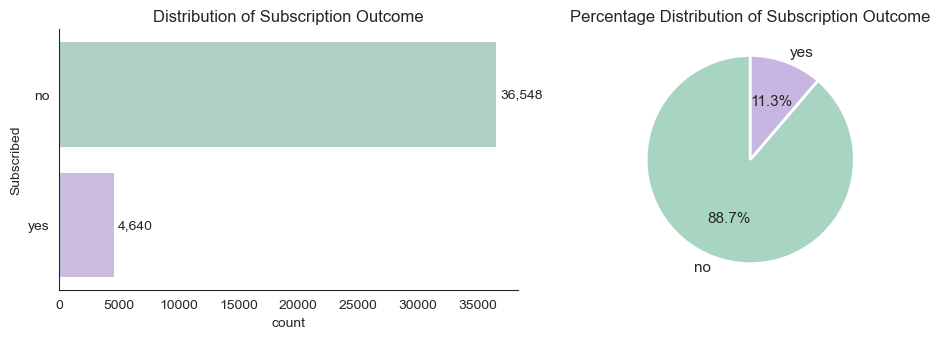


----------------------------------------
BUSINESS INTERPRETATION

Out of every 100 clients contacted by the campaign:
  • 11 subscribed to a term deposit
  • 89 did not subscribe

This means roughly 9 calls are needed per successful conversion 
under the current strategy. Any targeting improvement should be measured 
against this baseline of 11.27%.



In [12]:
# Visualization — side-by-side count and percentage
sns.set_style("white")

target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Pastel colors matching the reference style
colors = ['#a8d5c2', '#c8b6e2']  # soft teal for 'no', soft purple for 'yes'

# Horizontal bar chart of counts
sns.barplot(x=target_counts.values, y=target_counts.index,
            hue=target_counts.index, palette=colors,
            ax=axes[0], edgecolor='none', legend=False)
axes[0].set_title('Distribution of Subscription Outcome', fontsize=12)
axes[0].set_xlabel('count')
axes[0].set_ylabel('Subscribed')

# Add count labels at the end of each bar
for i, v in enumerate(target_counts.values):
    axes[0].text(v + 300, i, f'{v:,}', va='center', fontsize=10)

# Remove top and right spines
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart of percentages
axes[1].pie(target_counts.values,
            labels=target_counts.index,
            colors=colors,
            startangle=90,
            autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[1].set_title('Percentage Distribution of Subscription Outcome', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "-"*40)

print("BUSINESS INTERPRETATION")
print(f"""
Out of every 100 clients contacted by the campaign:
  • {target_pct['yes']:.0f} subscribed to a term deposit
  • {target_pct['no']:.0f} did not subscribe

This means roughly {100/target_pct['yes']:.0f} calls are needed per successful conversion 
under the current strategy. Any targeting improvement should be measured 
against this baseline of {target_pct['yes']:.2f}%.
""")

In [13]:
# Class imbalance ratio

imbalance_ratio = target_counts['no'] / target_counts['yes']
print(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"For every 1 subscriber, there are {imbalance_ratio:.1f} non-subscribers")

Class imbalance ratio: 7.88:1
For every 1 subscriber, there are 7.9 non-subscribers


In [14]:
# Campaign cost efficiency framing

total_calls = len(df)
total_conversions = target_counts['yes']
calls_per_conversion = total_calls / total_conversions

print(f"Total calls made:         {total_calls:,}")
print(f"Total subscriptions:      {total_conversions:,}")
print(f"Calls per subscription:   {calls_per_conversion:.1f}")
print(f"Non-conversion calls:     {target_counts['no']:,}")
print(f"Effort waste rate:        {target_counts['no']/total_calls*100:.1f}%")

Total calls made:         41,188
Total subscriptions:      4,640
Calls per subscription:   8.9
Non-conversion calls:     36,548
Effort waste rate:        88.7%


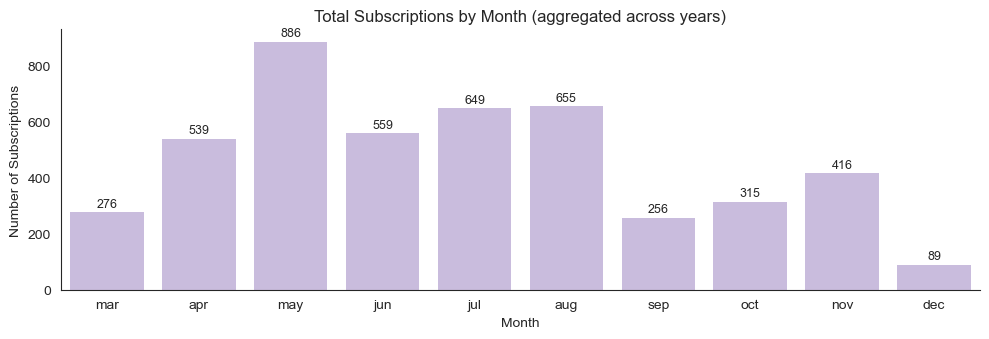

In [15]:
# Simple monthly subscription count
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
monthly = df[df['y']=='yes'].groupby('month').size().reindex(month_order).fillna(0)

plt.figure(figsize=(10, 3.5))
sns.barplot(x=monthly.index, y=monthly.values, color='#c8b6e2', edgecolor='none')
plt.title('Total Subscriptions by Month (aggregated across years)', fontsize=12)
plt.ylabel('Number of Subscriptions')
plt.xlabel('Month')
for i, v in enumerate(monthly.values):
    plt.text(i, v + 20, f'{int(v):,}', ha='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

### Key Findings

- **Baseline conversion rate: 11.27%.** Of 41,188 contacted clients, 4,640 subscribed and 36,548 did not. This is the benchmark every downstream analysis is measured against.
- **Class imbalance 7.88:1.** Meaningful but not extreme. Analysis should focus on *lift over baseline* rather than raw counts.
- **Current efficiency is low — ~9 calls per subscriber.** 88.7% of calls represent wasted effort, quantifying the room for improvement and motivating the entire project.
- **Subscription volume is highly uneven across months.** May leads (886), followed by August (655), July (649), April (539). December (89) and September (256) are lowest.

⚠️ **Important caveat:** absolute subscription counts reflect both *call volume* and *conversion rate*. A month with 886 subscriptions may still have a lower conversion rate than a month with 276 if it was called far more heavily.

### Business Implications

The baseline sets up the project's core question: **can targeted strategies beat 11.27% conversion with fewer calls?** The 88.7% waste rate quantifies exactly how much room for improvement exists.


#### PHASE 3 — UNIVARIATE ANALYSIS

In [16]:
# Identify numeric and categorical columns (exclude target)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove helper/derived columns
for col in ['unknown_count', 'y_binary']:
    if col in numeric_cols:
        numeric_cols.remove(col)
        
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('y')  # exclude target

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [17]:
# NUMERIC VARIABLE DISTRIBUTIONS

# Summary statistics
print("NUMERIC VARIABLE SUMMARY")
print(df[numeric_cols].describe().round(2).T.to_string())
print("\n" + "-"*40)


# Skewness and kurtosis
print("SKEWNESS & KURTOSIS")
skew_kurt = pd.DataFrame({
    'skewness': df[numeric_cols].skew().round(2),
    'kurtosis': df[numeric_cols].kurtosis().round(2)
})
print(skew_kurt)
print("""
Interpretation guide:
  Skewness:  0 = symmetric, >1 = right-skewed, <-1 = left-skewed
  Kurtosis:  0 = normal, >3 = heavy tails (outliers), <0 = flat
""")

NUMERIC VARIABLE SUMMARY
                  count     mean     std      min      25%      50%      75%      max
age             41188.0    40.02   10.42    17.00    32.00    38.00    47.00    98.00
duration        41188.0   258.29  259.28     0.00   102.00   180.00   319.00  4918.00
campaign        41188.0     2.57    2.77     1.00     1.00     2.00     3.00    56.00
pdays           41188.0   962.48  186.91     0.00   999.00   999.00   999.00   999.00
previous        41188.0     0.17    0.49     0.00     0.00     0.00     0.00     7.00
emp.var.rate    41188.0     0.08    1.57    -3.40    -1.80     1.10     1.40     1.40
cons.price.idx  41188.0    93.58    0.58    92.20    93.08    93.75    93.99    94.77
cons.conf.idx   41188.0   -40.50    4.63   -50.80   -42.70   -41.80   -36.40   -26.90
euribor3m       41188.0     3.62    1.73     0.63     1.34     4.86     4.96     5.04
nr.employed     41188.0  5167.02   72.18  4964.00  5099.00  5191.00  5228.00  5228.00

----------------------------

In [18]:
# CATEGORICAL VARIABLE DISTRIBUTIONS

print("CATEGORICAL COLUMNS:\n")
for col in categorical_cols:
    n_unique = df[col].nunique()
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    print(f"  {col} ({n_unique} unique values):")
    # Find the max percentage to scale bars (longest bar = ~30 chars)
    max_pct = pct.max()
    max_bar_length = 30
    for category, count in counts.items():
        percentage = pct[category]
        bar_length = int((percentage / max_pct) * max_bar_length)
        bar = '█' * bar_length
        print(f"    {str(category):<20} {count:>6,}  ({percentage:>5.1f}%) {bar}")
    print("  " + "-" * 80)
    print()

CATEGORICAL COLUMNS:

  job (12 unique values):
    admin.               10,422  ( 25.3%) ██████████████████████████████
    blue-collar           9,254  ( 22.5%) ██████████████████████████
    technician            6,743  ( 16.4%) ███████████████████
    services              3,969  (  9.6%) ███████████
    management            2,924  (  7.1%) ████████
    retired               1,720  (  4.2%) ████
    entrepreneur          1,456  (  3.5%) ████
    self-employed         1,421  (  3.5%) ████
    housemaid             1,060  (  2.6%) ███
    unemployed            1,014  (  2.5%) ██
    student                 875  (  2.1%) ██
    unknown                 330  (  0.8%) 
  --------------------------------------------------------------------------------

  marital (4 unique values):
    married              24,928  ( 60.5%) ██████████████████████████████
    single               11,568  ( 28.1%) █████████████
    divorced              4,612  ( 11.2%) █████
    unknown                  80  

### Numeric Variables — Key Findings

- **`campaign` is the most extreme distribution** (skewness 4.76, max 56 contacts). Most clients were contacted 1–3 times; the long tail is operational edge cases and will be capped at 10 during cleaning.
- **`duration` is heavily right-skewed** (max 4,918 sec / 82 min). Analytically interesting but a **leakage variable** — known only after the call ends. Excluded from any predictive framework.
- **`pdays` is dominated by the sentinel value 999.** The 25th, 50th, and 75th percentiles are all 999, meaning ≥75% of clients were never previously contacted. Must be transformed into a binary flag + clean numeric during cleaning.
- **Macroeconomic variables show flat, clustered distributions** (negative kurtosis). Expected — they are quarterly/monthly indicators repeated across many rows.
- **`age` is roughly normal** with a mild right skew. Median 38, max 98. Elderly clients are legitimate retirees, not outliers to remove.

### Categorical Variables — Key Findings

- **Call volume is extremely concentrated in summer months.** May alone accounts for **33.4%** of all calls; May–Aug together make up **78.8%**. March, September, October, and December combined account for less than 5%. This volume imbalance is the most important descriptive finding so far.
- **Admin, blue-collar, and technician dominate** the client base (64% of contacts). Students (2.1%) and retirees (4.2%) are small in volume — Phase 5 will test whether they punch above their weight in conversion.
- **`default = yes` is effectively non-existent** — only 3 clients out of 41,188. The column functionally operates as a binary no (79%) vs unknown (21%) split.
- **86.3% of clients have no previous campaign history** (`poutcome = nonexistent`). Only 1,373 (3.3%) have a previous success — a small but likely high-value subgroup.
- **Day of week is uniformly distributed** (19–21% each, Mon–Fri). Balanced groups for A/B testing but likely a minor lever.
- **Contact channel is reasonably balanced** (cellular 63.5%, telephone 36.5%). Both large enough for statistically powerful comparison.

### Cleaning Actions Required

| Column    | Issue                       | Treatment                                |
|-----------|-----------------------------|------------------------------------------|
| pdays     | 999 sentinel dominates      | Split into binary flag + clean numeric   |
| campaign  | Extreme tail (max 56)       | Cap at 10                                |
| duration  | Leakage variable            | Exclude from predictive framework        |
| default   | 3 "yes" cases only          | Treat as effectively binary              |

The extreme month imbalance frames the central analytical question for later phases: **is the bank allocating its call effort to the right months?**

#### PHASE 4 — CATEGORICAL FEATURES vs TARGET

In [19]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                    'contact', 'month', 'day_of_week', 'poutcome']

baseline = (df['y'] == 'yes').mean() * 100

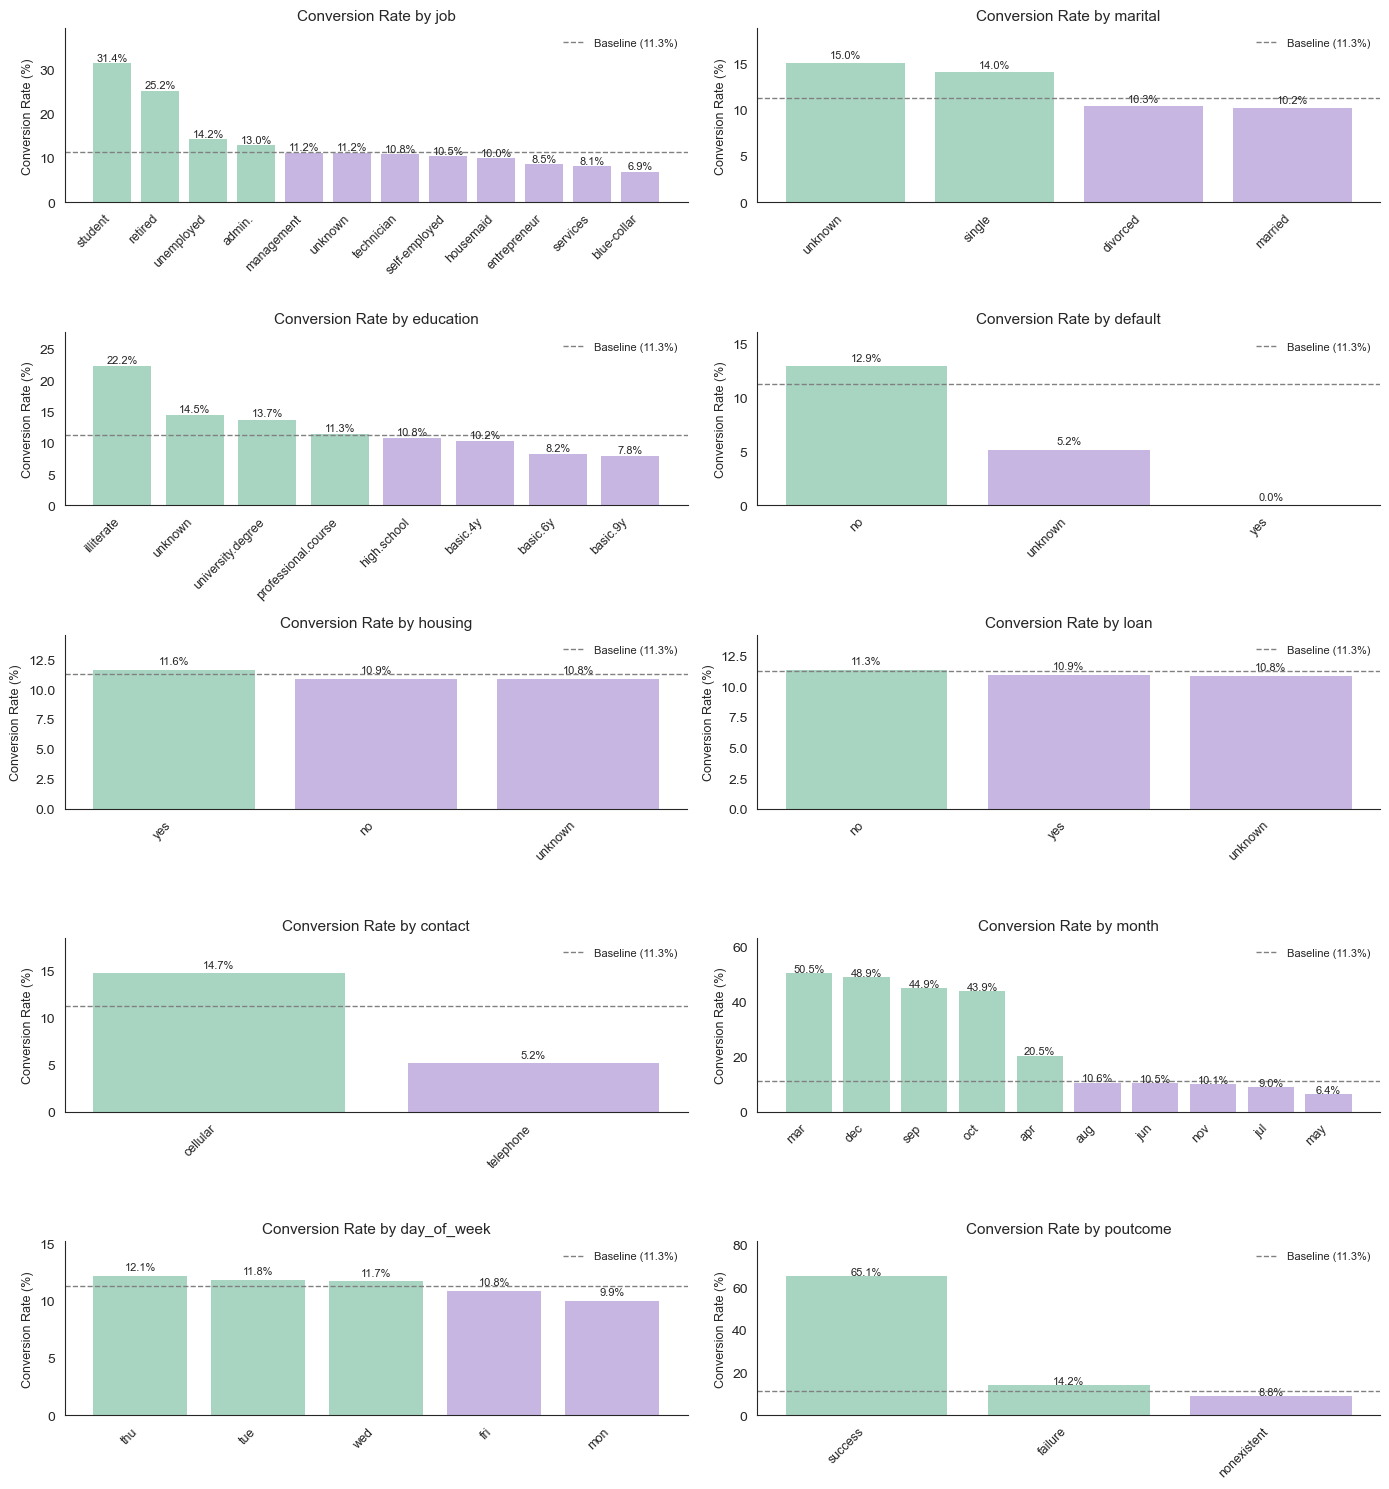

In [20]:
# CONVERSION RATE VISUALIZATION
sns.set_style("white")

# Create y_binary if it doesn't exist
df['y_binary'] = (df['y'] == 'yes').astype(int)

n_cols = len(categorical_cols)
n_rows = (n_cols + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 3))
axes = axes.flatten()

# Pastel colors: teal for above baseline, purple for below
above_color = '#a8d5c2'
below_color = '#c8b6e2'

for i, col in enumerate(categorical_cols):
    conv_rate = df.groupby(col)['y_binary'].mean().sort_values(ascending=False) * 100
    colors = [above_color if v >= baseline else below_color for v in conv_rate.values]

    axes[i].bar(range(len(conv_rate)), conv_rate.values,
                color=colors, edgecolor='none')
    axes[i].axhline(baseline, color='gray', linestyle='--', linewidth=1,
                    label=f'Baseline ({baseline:.1f}%)')
    axes[i].set_xticks(range(len(conv_rate)))
    axes[i].set_xticklabels(conv_rate.index, rotation=45, ha='right', fontsize=9)
    axes[i].set_title(f'Conversion Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Conversion Rate (%)', fontsize=9)
    axes[i].set_ylim(0, max(conv_rate.values) * 1.25)
    axes[i].legend(fontsize=8, loc='upper right', frameon=False)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    for j, v in enumerate(conv_rate.values):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8)

for j in range(len(categorical_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [21]:
# TOP & BOTTOM CONVERTING SEGMENTS
print("TOP & BOTTOM CONVERTING SEGMENTS")
print(f"  Baseline conversion rate: {baseline:.2f}%")
print(f"  Filter: segments with at least 100 clients\n")

all_segments = []
for col in categorical_cols:
    seg = df.groupby(col).agg(
        total=('y_binary', 'count'),
        conv_rate=('y_binary', 'mean')
    )
    seg['conv_rate'] = seg['conv_rate'] * 100
    seg['feature'] = col
    seg = seg.reset_index().rename(columns={col: 'category'})
    all_segments.append(seg[['feature', 'category', 'total', 'conv_rate']])

all_segments_df = pd.concat(all_segments, ignore_index=True)
all_segments_df = all_segments_df[all_segments_df['total'] >= 100]
all_segments_df['conv_rate'] = all_segments_df['conv_rate'].round(2)

print("  TOP 10 HIGHEST-CONVERTING SEGMENTS:")
top10 = all_segments_df.nlargest(10, 'conv_rate')
for _, row in top10.iterrows():
    label = f"{row['feature']}={row['category']}"
    print(f"    {label:<28} {int(row['total']):>6,}  ({row['conv_rate']:>5.2f}%)")

print("  " + "-" * 60)
print()

print("  BOTTOM 10 LOWEST-CONVERTING SEGMENTS:")
bottom10 = all_segments_df.nsmallest(10, 'conv_rate').sort_values('conv_rate')
for _, row in bottom10.iterrows():
    label = f"{row['feature']}={row['category']}"
    print(f"    {label:<28} {int(row['total']):>6,}  ({row['conv_rate']:>5.2f}%)")

print()

TOP & BOTTOM CONVERTING SEGMENTS
  Baseline conversion rate: 11.27%
  Filter: segments with at least 100 clients

  TOP 10 HIGHEST-CONVERTING SEGMENTS:
    poutcome=success              1,373  (65.11%)
    month=mar                       546  (50.55%)
    month=dec                       182  (48.90%)
    month=sep                       570  (44.91%)
    month=oct                       718  (43.87%)
    job=student                     875  (31.43%)
    job=retired                   1,720  (25.23%)
    month=apr                     2,632  (20.48%)
    contact=cellular             26,144  (14.74%)
    education=unknown             1,731  (14.50%)
  ------------------------------------------------------------

  BOTTOM 10 LOWEST-CONVERTING SEGMENTS:
    default=unknown               8,597  ( 5.15%)
    contact=telephone            15,044  ( 5.23%)
    month=may                    13,769  ( 6.43%)
    job=blue-collar               9,254  ( 6.89%)
    education=basic.9y            6,045  ( 7

In [22]:
# LIFT OVER BASELINE
GREEN = '\033[92m'
RED = '\033[91m'
RESET = '\033[0m'

print("LIFT OVER BASELINE")
print("  (Lift = segment conversion rate / baseline conversion rate)")
print("  Lift > 1.0 → segment performs better than average")
print(f"  Baseline: {baseline:.2f}%\n")

for col in ['job', 'month', 'contact', 'poutcome']:
    print(f"  {col}:")
    lift = df.groupby(col)['y_binary'].mean() / (baseline / 100)
    lift = lift.sort_values(ascending=False).round(2)

    for cat, l in lift.items():
        if l > 1:
            indicator = f"{GREEN}↑{RESET}"
        else:
            indicator = f"{RED}↓{RESET}"
        print(f"    {str(cat):<20} {l:>5.2f}x  {indicator}")

    print("  " + "-" * 60)
    print()

LIFT OVER BASELINE
  (Lift = segment conversion rate / baseline conversion rate)
  Lift > 1.0 → segment performs better than average
  Baseline: 11.27%

  job:
    student               2.79x  ↑
    retired               2.24x  ↑
    unemployed            1.26x  ↑
    admin.                1.15x  ↑
    management            1.00x  ↓
    unknown               1.00x  ↓
    technician            0.96x  ↓
    self-employed         0.93x  ↓
    housemaid             0.89x  ↓
    entrepreneur          0.76x  ↓
    services              0.72x  ↓
    blue-collar           0.61x  ↓
  ------------------------------------------------------------

  month:
    mar                   4.49x  ↑
    dec                   4.34x  ↑
    sep                   3.99x  ↑
    oct                   3.89x  ↑
    apr                   1.82x  ↑
    aug                   0.94x  ↓
    jun                   0.93x  ↓
    nov                   0.90x  ↓
    jul                   0.80x  ↓
    may                   0.57x 

### Headline Finding — Volume vs. Effectiveness Mismatch

The bank's call volume is inversely related to campaign effectiveness. May alone accounts for **33.4% of all calls but has the lowest conversion rate (6.4%, 0.57x lift)**. Meanwhile March, December, September, and October — the four highest-converting months (44–51%, ~4x lift) — collectively make up less than 5% of call volume. This is the single most actionable finding in the dataset.

### Other Key Findings

- **Previous campaign success is the strongest single predictor.** Clients with `poutcome = success` convert at 65.1% (5.78x lift). Even previous *failures* convert above baseline (14.2%), suggesting any prior contact helps.
- **Job segment disparity is ~4x.** Students (31.4%) and retirees (25.2%) lead; blue-collar (6.9%) and services (8.1%) trail. Blue-collar is the largest segment by volume but the worst by conversion.
- **Cellular beats telephone by 2.8x** (14.7% vs 5.2%). ~15,000 telephone calls represent effort spent on the weaker channel.
- **`default = unknown` converts at 5.15%**, confirming the Phase 2 finding that evasive clients behave differently. The 3 `default = yes` rows are statistically meaningless.
- **Day of week has minimal impact** — only a 2.2 pp spread (Mon 9.9% → Thu 12.1%). Unlikely to be a major lever.
- **Education and marital effects are modest.** University degree holders (13.7%) and singles (14.0%) slightly outperform baseline.

### Emerging Ideal Customer Profile

Retired or student, contacted via cellular, in March/Sept/Oct/Dec, with a previous campaign success (or any prior contact). This is directional — the A/B testing phase will validate which gaps are statistically significant.

### Caveats

Small segments (illiterate n=18, default=yes n=3, marital=unknown n=80) cannot support inference. The month effect may be confounded with macroeconomic conditions — this will be disentangled in the temporal analysis phase.

#### PHASE 6 — OUTLIER DETECTION & TREATMENT DECISIONS

In [23]:
# Columns that warrant deep outlier inspection
# (macroeconomic variables are excluded — their "outliers" are real economic conditions)
outlier_targets = ['age', 'duration', 'campaign', 'pdays', 'previous']

In [24]:
# 6.1 IQR METHOD — BASELINE OUTLIER COUNT

print("IQR OUTLIER DETECTION")

outlier_details = []
for col in outlier_targets:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_mask = (df[col] < lower) | (df[col] > upper)
    outliers = df[outliers_mask]

    outlier_details.append({
        'column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': len(outliers),
        'outlier_pct': round(len(outliers) / len(df) * 100, 2),
        'min_value': df[col].min(),
        'max_value': df[col].max()
    })

outlier_df = pd.DataFrame(outlier_details)
print(outlier_df.to_string(index=False))

IQR OUTLIER DETECTION
  column    Q1    Q3   IQR  lower_bound  upper_bound  outlier_count  outlier_pct  min_value  max_value
     age  32.0  47.0  15.0          9.5         69.5            469         1.14         17         98
duration 102.0 319.0 217.0       -223.5        644.5           2963         7.19          0       4918
campaign   1.0   3.0   2.0         -2.0          6.0           2406         5.84          1         56
   pdays 999.0 999.0   0.0        999.0        999.0           1515         3.68          0        999
previous   0.0   0.0   0.0          0.0          0.0           5625        13.66          0          7


In [25]:
# 6.2 Z-SCORE METHOD — SECOND OPINION

print("Z-SCORE OUTLIER DETECTION (|z| > 3)")

from scipy import stats

z_outliers = []
for col in outlier_targets:
    z_scores = np.abs(stats.zscore(df[col]))
    count = (z_scores > 3).sum()
    z_outliers.append({
        'column': col,
        'z>3_count': count,
        'z>3_pct': round(count / len(df) * 100, 2)
    })

print(pd.DataFrame(z_outliers).to_string(index=False))

Z-SCORE OUTLIER DETECTION (|z| > 3)
  column  z>3_count  z>3_pct
     age        369     0.90
duration        861     2.09
campaign        869     2.11
   pdays       1515     3.68
previous       1064     2.58


In [26]:
# COLUMN-BY-COLUMN INVESTIGATION

# ---------- AGE ----------
print("-----AGE — DEEP DIVE-----")
print(f"Min: {df['age'].min()}, Max: {df['age'].max()}")
print(f"Clients over 80: {(df['age'] > 80).sum()}")
print(f"Clients over 90: {(df['age'] > 90).sum()}")
print(f"Conversion rate for clients over 60: {(df[df['age']>60]['y']=='yes').mean()*100:.2f}%")
print(f"Overall conversion rate: {(df['y']=='yes').mean()*100:.2f}%")
print("\nDecision: KEEP. Elderly clients are legitimate retirees, a high-converting segment.")

print("\n" + "-"*40)

# ---------- DURATION ----------
print("-----DURATION — DEEP DIVE-----")
print(f"Min: {df['duration'].min()} sec, Max: {df['duration'].max()} sec ({df['duration'].max()/60:.1f} min)")
print(f"Calls with duration = 0: {(df['duration']==0).sum()}")
print(f"Calls over 30 min (1800 sec): {(df['duration']>1800).sum()}")
print(f"Calls over 60 min (3600 sec): {(df['duration']>3600).sum()}")

# Duration vs conversion by bucket
df['duration_bucket'] = pd.cut(df['duration'],
                                bins=[-1, 60, 180, 300, 600, 1200, 5000],
                                labels=['<1min', '1-3min', '3-5min', '5-10min', '10-20min', '20+min'])
print("\nConversion by duration bucket:")
print(df.groupby('duration_bucket', observed=True)['y'].apply(
    lambda x: f"{(x=='yes').mean()*100:.1f}%"
))
print("\nDecision: FLAG but do not remove. Duration is a leakage variable — ")
print("exclude from modeling but keep for descriptive analysis.")

print("\n" + "-"*40)

# ---------- CAMPAIGN ----------
print("-----CAMPAIGN (contact frequency) — DEEP DIVE-----")
print(f"Min: {df['campaign'].min()}, Max: {df['campaign'].max()}")
print(f"Clients contacted more than 10 times: {(df['campaign']>10).sum()}")
print(f"Clients contacted more than 20 times: {(df['campaign']>20).sum()}")
print(f"Clients contacted more than 30 times: {(df['campaign']>30).sum()}")

# Conversion by campaign bucket — important for the diminishing returns A/B test
df['campaign_bucket'] = pd.cut(df['campaign'],
                                bins=[0, 1, 2, 3, 5, 10, 60],
                                labels=['1', '2', '3', '4-5', '6-10', '11+'])
print("\nConversion by number of contacts:")
print(df.groupby('campaign_bucket', observed=True).agg(
    clients=('y', 'count'),
    conversion=('y', lambda x: round((x=='yes').mean()*100, 2))
))
print("\nDecision: CAP at 10. Cases with 11+ contacts are rare and")
print("likely reflect operational errors or persistence with poor-fit clients.")

print("\n" + "-"*40)

# ---------- PDAYS ----------
print("-----PDAYS — DEEP DIVE-----")
print(f"Clients with pdays = 999 (never previously contacted): {(df['pdays']==999).sum():,}")
print(f"Percentage of dataset: {(df['pdays']==999).mean()*100:.1f}%")
print(f"Max pdays excluding 999: {df[df['pdays']!=999]['pdays'].max()}")
print(f"Conversion rate for pdays=999: {(df[df['pdays']==999]['y']=='yes').mean()*100:.2f}%")
print(f"Conversion rate for pdays<999: {(df[df['pdays']!=999]['y']=='yes').mean()*100:.2f}%")
print("\nDecision: TRANSFORM. Create a binary flag 'was_previously_contacted'")
print("and replace 999 with NaN or 0 for the numeric column.")

print("\n" + "-"*40)

# ---------- PREVIOUS ----------
print("-----PREVIOUS (prior contacts) — DEEP DIVE-----")
print(f"Distribution of 'previous':")
print(df['previous'].value_counts().sort_index())
print(f"\nConversion rate for previous = 0: {(df[df['previous']==0]['y']=='yes').mean()*100:.2f}%")
print(f"Conversion rate for previous >= 1: {(df[df['previous']>=1]['y']=='yes').mean()*100:.2f}%")
print("\nDecision: KEEP. Extreme values are rare but meaningful (repeat contacts).")

-----AGE — DEEP DIVE-----
Min: 17, Max: 98
Clients over 80: 119
Clients over 90: 10
Conversion rate for clients over 60: 45.49%
Overall conversion rate: 11.27%

Decision: KEEP. Elderly clients are legitimate retirees, a high-converting segment.

----------------------------------------
-----DURATION — DEEP DIVE-----
Min: 0 sec, Max: 4918 sec (82.0 min)
Calls with duration = 0: 4
Calls over 30 min (1800 sec): 101
Calls over 60 min (3600 sec): 5

Conversion by duration bucket:
duration_bucket
<1min        0.0%
1-3min       3.4%
3-5min      10.3%
5-10min     18.6%
10-20min    46.2%
20+min      62.6%
Name: y, dtype: object

Decision: FLAG but do not remove. Duration is a leakage variable — 
exclude from modeling but keep for descriptive analysis.

----------------------------------------
-----CAMPAIGN (contact frequency) — DEEP DIVE-----
Min: 1, Max: 56
Clients contacted more than 10 times: 869
Clients contacted more than 20 times: 157
Clients contacted more than 30 times: 33

Conversion b

#### PHASE 7 — CORRELATION & MULTICOLLINEARITY ANALYSIS

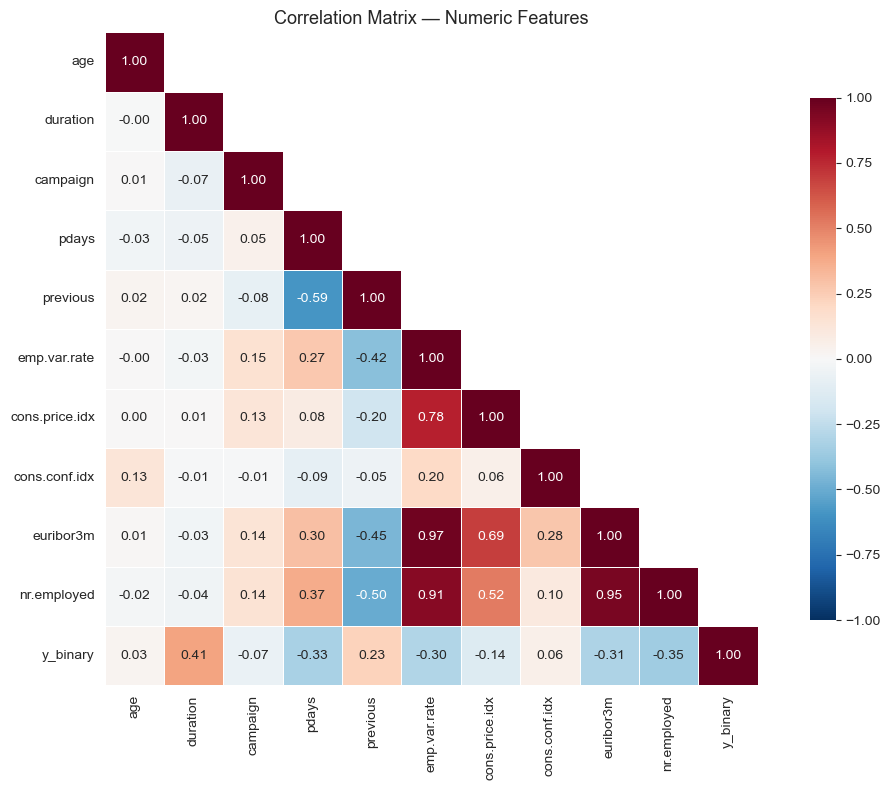

In [27]:
# Use clean numeric columns only
numeric_analysis = ['age', 'duration', 'campaign', 'pdays', 'previous',
                    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                    'euribor3m', 'nr.employed', 'y_binary']

# Correlation matrix
corr_matrix = df[numeric_analysis].corr(method='pearson').round(3)

# Heatmap visualization
plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, mask=mask,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()